# Diabetes Re-admission predection Project

In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, log_loss, classification_report
import warnings
warnings.filterwarnings('ignore')

In [3]:
df_diabetes = pd.read_csv('diabetic_data.csv')
df_diabetes.head()

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [4]:
df_diabetes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

# Data cleaning

## Check for missing values

From the information above, max_glu_serum and A1Cresult columns has missing values. Lets calculate what percent of values are missing.

In [4]:
# Function to find null value details
def func_to_find_null(colname, df):
    colname_null = df[colname].isnull().sum()
    colname_percentage_null = round((colname_null/df.shape[0])*100,2)
    print(f'{colname} column has {colname_null} i.e. {colname_percentage_null} % null values.')

In [5]:
func_to_find_null('max_glu_serum', df_diabetes)

max_glu_serum column has 96420 i.e. 94.75 % null values.


In [6]:
func_to_find_null('A1Cresult', df_diabetes)

A1Cresult column has 84748 i.e. 83.28 % null values.


max_glu_serum column has 94.75 % of values are missing and we can drop the column. OR if it is clinically important feature, we should check with SME if we can impute with mode i.e., "Norm".

A1Cresult column has 83.28 % of values are missing and we can drop the column. OR if it is a clinically important feature, we should check with SME if we can impute with mode i.e., ">8".

## Retrieving descriptions of the IDs mapped from IDS_mapping.csv

In [7]:
# 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', these columns have IDs mapped from IDS_mapping.csv
id_map = pd.read_csv('IDS_mapping.csv', header=None)
id_map

,0,1
0,admission_type_id,description
1,1,Emergency
2,2,Urgent
3,3,Elective
4,4,Newborn
...,...,...
63,22,Transfer from hospital inpt/same fac reslt in...
64,23,Born inside this hospital
65,24,Born outside this hospital
66,25,Transfer from Ambulatory Surgery Center


In [8]:
# Extracting admission_type_id information as a DF
df_admission_type_id = id_map.loc[id_map.loc[id_map[0]=='admission_type_id',0].index[0]:id_map.loc[id_map[0]=='admission_type_id',0].index[0]+8]

In [9]:
# Extracting discharge_disposition_id information as a DF
df_discharge_disposition_id = id_map.loc[id_map.loc[id_map[0]=='discharge_disposition_id',0].index[0]:id_map.loc[id_map[0]=='discharge_disposition_id',0].index[0]+30]

In [10]:
# Extracting admission_source_id information as a DF
df_admission_source_id = id_map.loc[id_map.loc[id_map[0]=='admission_source_id',0].index[0]:id_map.loc[id_map[0]=='admission_source_id',0].index[0]+27]

In [11]:
#Function to clean (updating column names, reset index, etc) IDs DFs
def clean_mappingfile(mappingDF):
    mappingDF.columns = mappingDF.iloc[0]
    mappingDF.reset_index(inplace=True)
    mappingDF.drop(0, inplace=True)
    mappingDF.drop(mappingDF.columns[0], axis=1, inplace=True)

In [12]:
clean_mappingfile(df_admission_source_id)
clean_mappingfile(df_admission_type_id)
clean_mappingfile(df_discharge_disposition_id)

In [13]:
# Giving meaningful column name for Description columns
df_admission_source_id.columns.values[1] = 'admission_source'
df_admission_type_id.columns.values[1] = 'admission_type'
df_discharge_disposition_id.columns.values[1] = 'discharge_disposition'

In [14]:
# Typecasting IDs column to numeric
df_admission_source_id['admission_source_id'] = df_admission_source_id.iloc[:,0].astype(int)
df_admission_type_id['admission_type_id'] = df_admission_type_id.iloc[:,0].astype(int)
df_discharge_disposition_id['discharge_disposition_id'] = df_discharge_disposition_id.iloc[:,0].astype(int)

In [15]:
# Merging with main DF
df_diabetes = df_diabetes.merge(df_admission_source_id, how='left', on='admission_source_id')
df_diabetes = df_diabetes.merge(df_admission_type_id, how='left', on='admission_type_id')
df_diabetes = df_diabetes.merge(df_discharge_disposition_id, how='left', on='discharge_disposition_id')

In [16]:
# Dropping IDs(source) columns
df_diabetes.drop(['admission_type_id', 'discharge_disposition_id', 'admission_source_id'], axis=1, inplace=True)

In [17]:
# Check for null values
func_to_find_null('admission_source', df_diabetes)
func_to_find_null('admission_type', df_diabetes)
func_to_find_null('discharge_disposition', df_diabetes)

admission_source column has 6781 i.e. 6.66 % null values.
admission_type column has 5291 i.e. 5.2 % null values.
discharge_disposition column has 3691 i.e. 3.63 % null values.


In [18]:
df_diabetes['admission_source'].value_counts(dropna=False)

admission_source
 Emergency Room                                               57494
 Physician Referral                                           29565
NaN                                                            6781
Transfer from a hospital                                       3187
 Transfer from another health care facility                    2264
Clinic Referral                                                1104
 Transfer from a Skilled Nursing Facility (SNF)                 855
HMO Referral                                                    187
 Not Mapped                                                     161
 Not Available                                                  125
 Court/Law Enforcement                                           16
 Transfer from hospital inpt/same fac reslt in a sep claim       12
 Transfer from critial access hospital                            8
 Extramural Birth                                                 2
Normal Delivery                

In [19]:
df_diabetes['admission_type'].value_counts(dropna=False)

admission_type
Emergency        53990
Elective         18869
Urgent           18480
NaN               5291
Not Available     4785
Not Mapped         320
Trauma Center       21
Newborn             10
Name: count, dtype: int64

In [20]:
df_diabetes['discharge_disposition'].value_counts(dropna=False)

discharge_disposition
Discharged to home                                                                                           60234
Discharged/transferred to SNF                                                                                13954
Discharged/transferred to home with home health service                                                      12902
NaN                                                                                                           3691
Discharged/transferred to another short term hospital                                                         2128
Discharged/transferred to another rehab fac including rehab units of a hospital .                             1993
Expired                                                                                                       1642
Discharged/transferred to another type of inpatient care institution                                          1184
Not Mapped                                                

Since admission_source column has 6781 i.e. 6.66 % null values, we can impute it with "Not Available", considering not to bilindly impute with most frequent value, as it may false interpret the data. Advise needed on this.

Same decision for admission_type column.

Same decision for discharge_disposition column, but mapping to "Not Mapped".

## Explore the dataset for unique values in each column

In [21]:
for x in df_diabetes.select_dtypes('object'):
    print(df_diabetes[x].value_counts())
    print("--"*20)

race
Caucasian          76099
AfricanAmerican    19210
?                   2273
Hispanic            2037
Other               1506
Asian                641
Name: count, dtype: int64
----------------------------------------
gender
Female             54708
Male               47055
Unknown/Invalid        3
Name: count, dtype: int64
----------------------------------------
age
[70-80)     26068
[60-70)     22483
[50-60)     17256
[80-90)     17197
[40-50)      9685
[30-40)      3775
[90-100)     2793
[20-30)      1657
[10-20)       691
[0-10)        161
Name: count, dtype: int64
----------------------------------------
weight
?            98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64
----------------------------------------
payer_code
?     40256
MC    32439
HM     6274
SP     5007
BC     4655
MD     3532
CP     2533
UN     2448
CM     

In [22]:
categorical_columns = df_diabetes.select_dtypes(include=['object']).columns

for col in categorical_columns:
    percentage_distribution = df_diabetes[col].value_counts(normalize=True) * 100
    print(f"Percentage distribution for {col}:\n{percentage_distribution}\n")

Percentage distribution for race:
race
Caucasian          74.778413
AfricanAmerican    18.876639
?                   2.233555
Hispanic            2.001651
Other               1.479866
Asian               0.629876
Name: proportion, dtype: float64

Percentage distribution for gender:
gender
Female             53.758623
Male               46.238429
Unknown/Invalid     0.002948
Name: proportion, dtype: float64

Percentage distribution for age:
age
[70-80)     25.615628
[60-70)     22.092840
[50-60)     16.956547
[80-90)     16.898571
[40-50)      9.516931
[30-40)      3.709490
[90-100)     2.744532
[20-30)      1.628245
[10-20)      0.679009
[0-10)       0.158206
Name: proportion, dtype: float64

Percentage distribution for weight:
weight
?            96.858479
[75-100)      1.312816
[50-75)       0.881434
[100-125)     0.614154
[125-150)     0.142484
[25-50)       0.095317
[0-25)        0.047167
[150-175)     0.034393
[175-200)     0.010809
>200          0.002948
Name: proportion, dtype: 

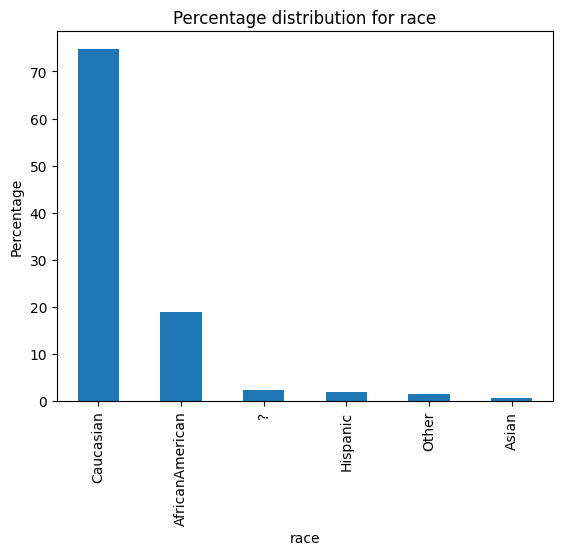

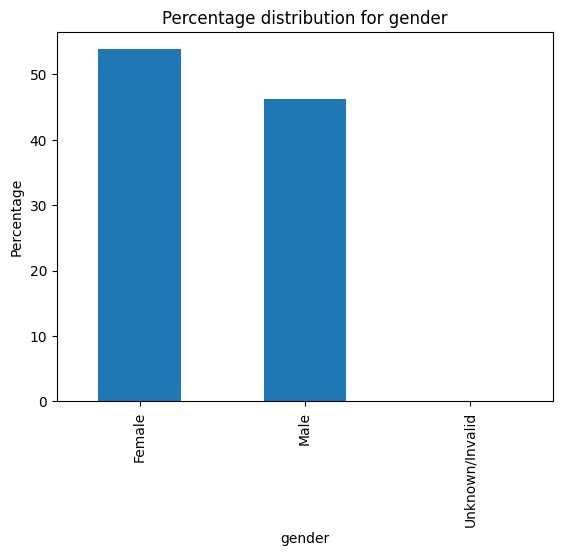

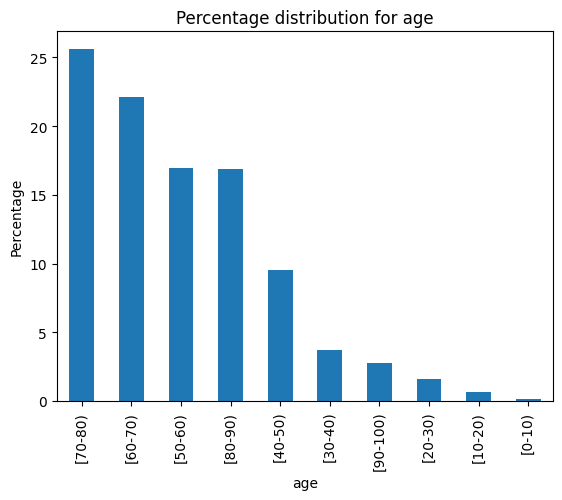

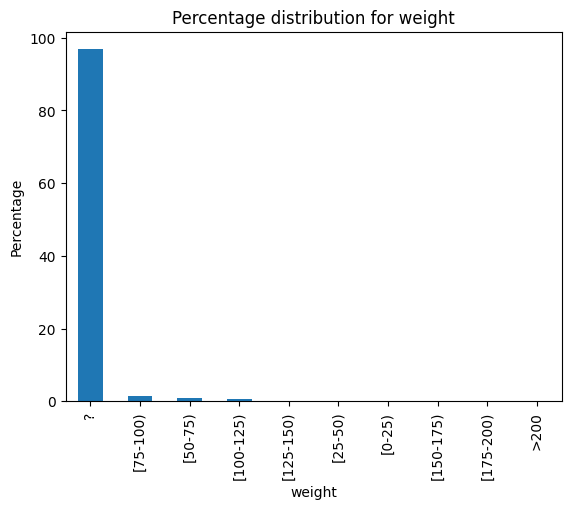

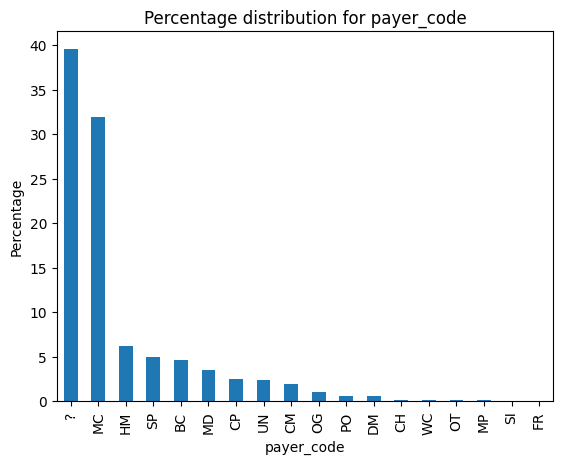

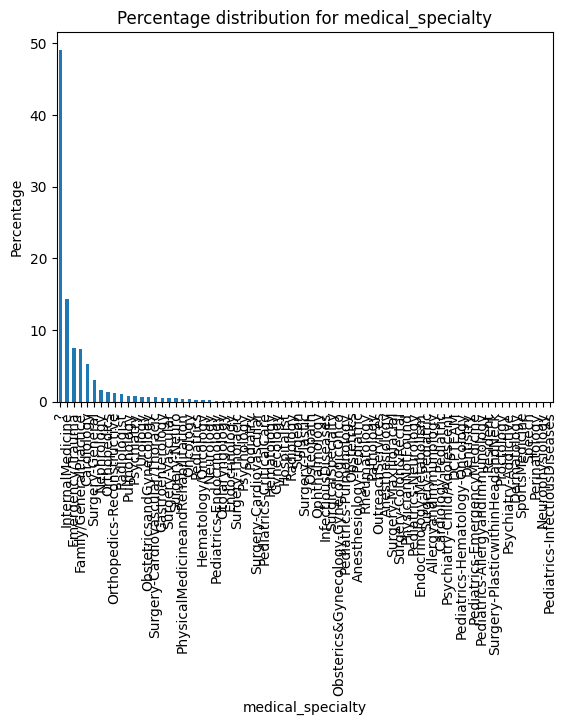

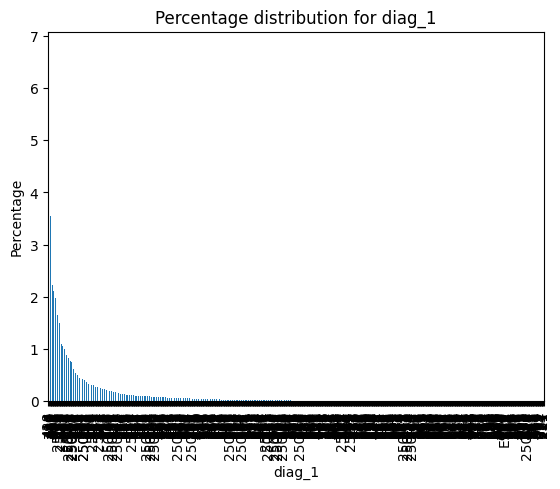

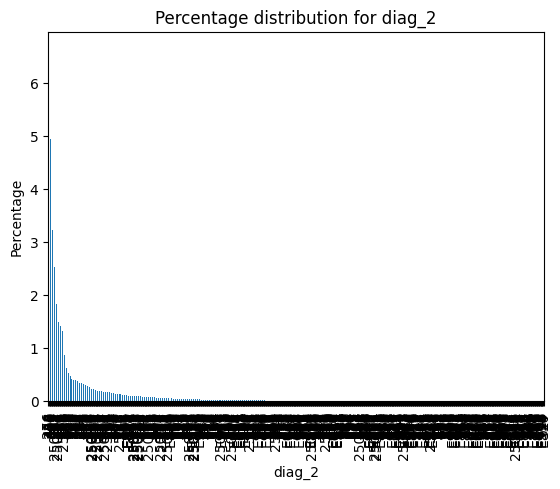

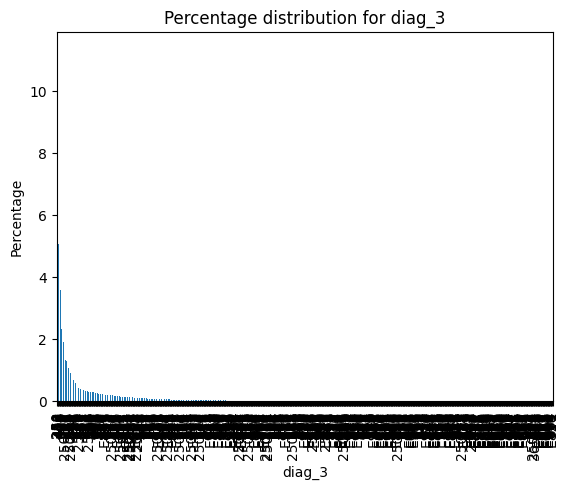

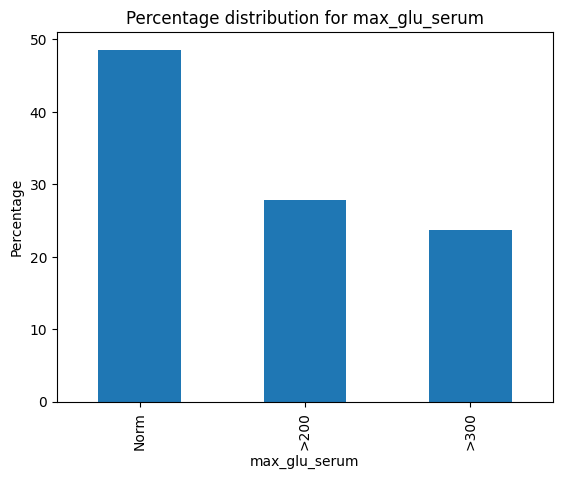

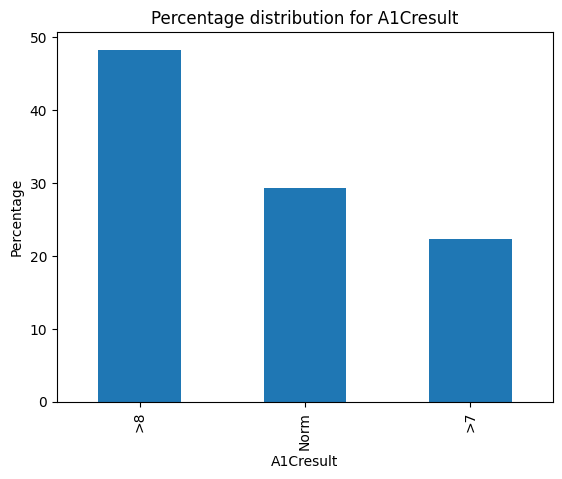

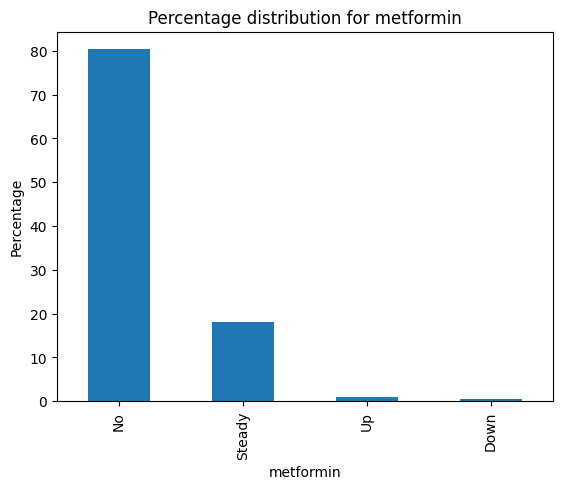

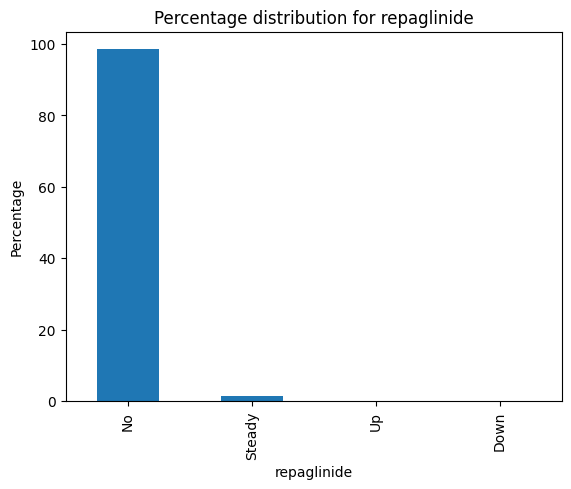

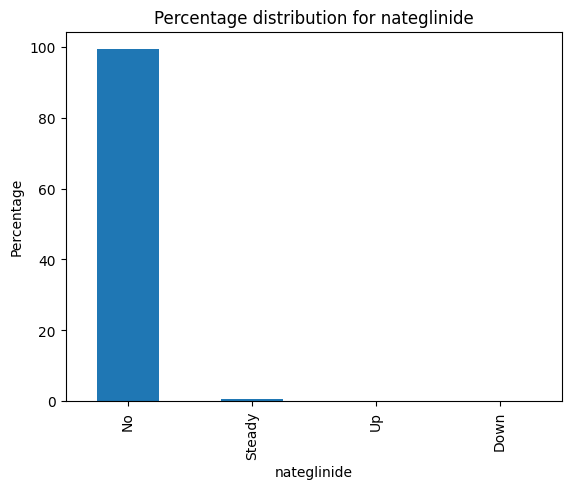

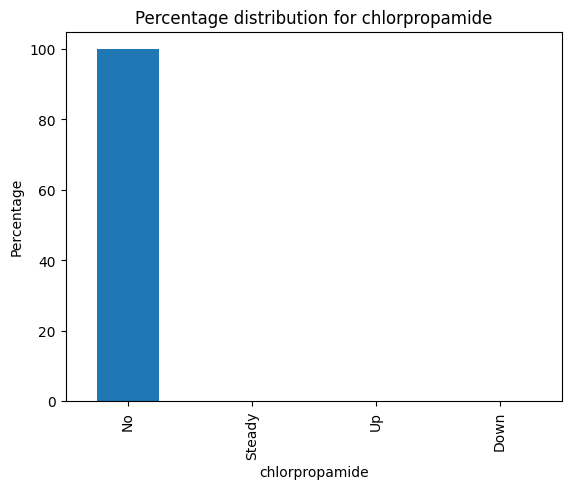

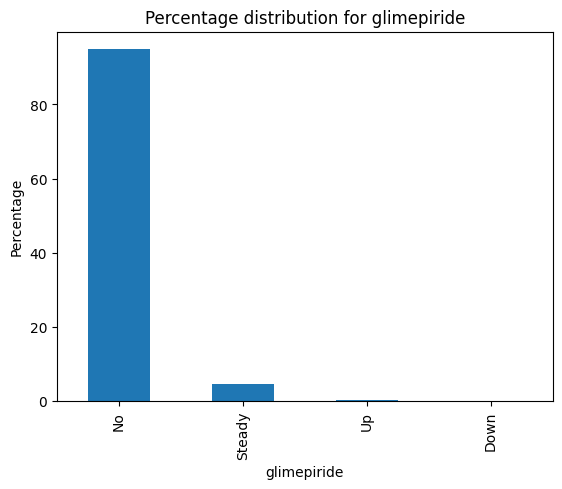

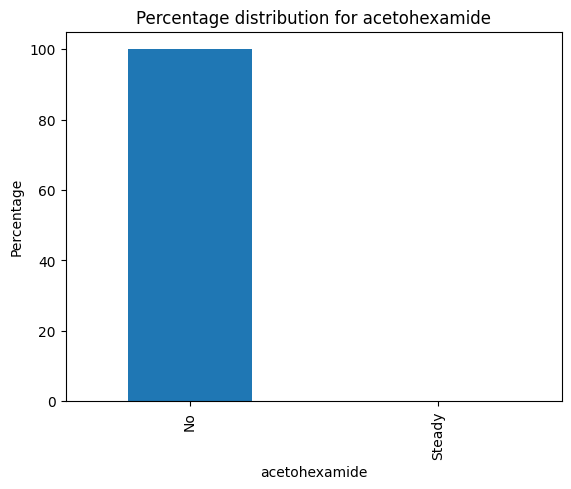

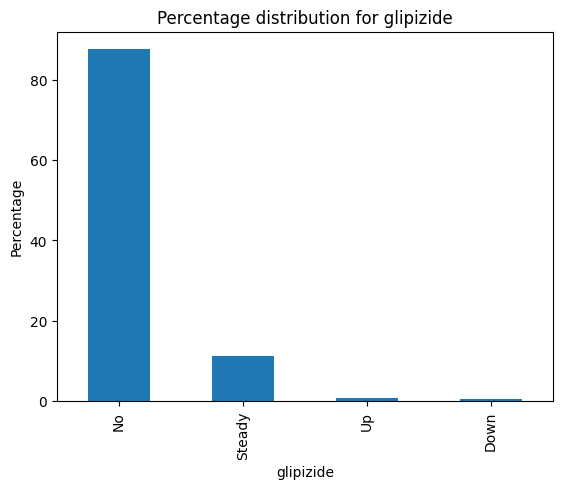

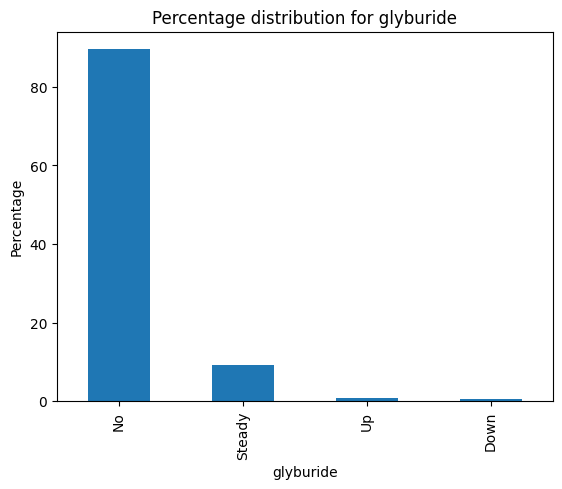

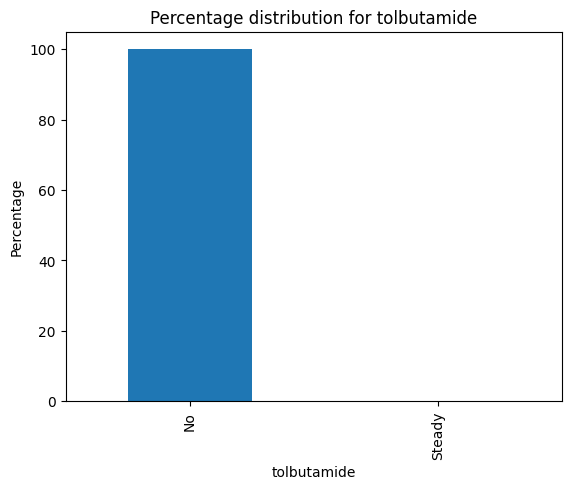

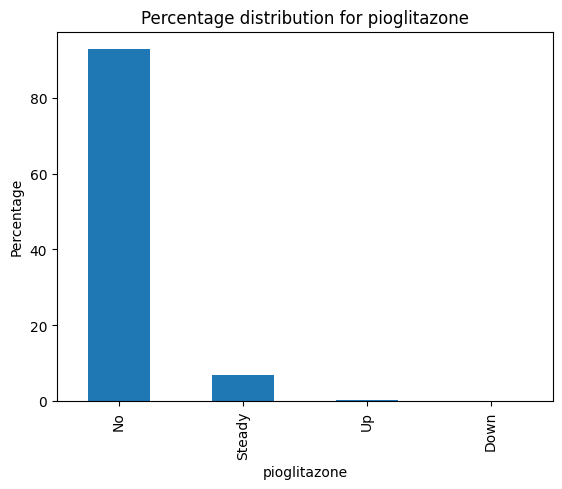

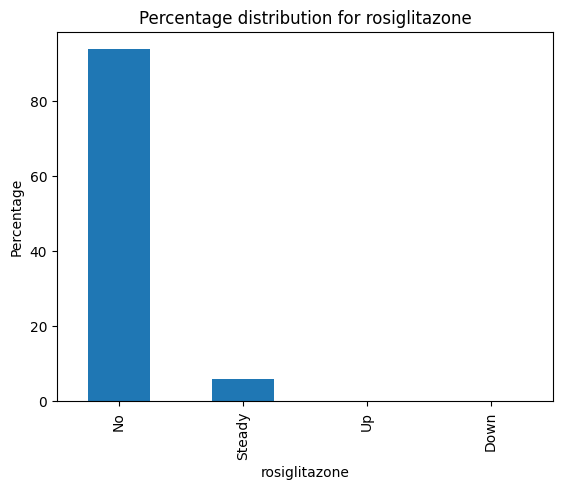

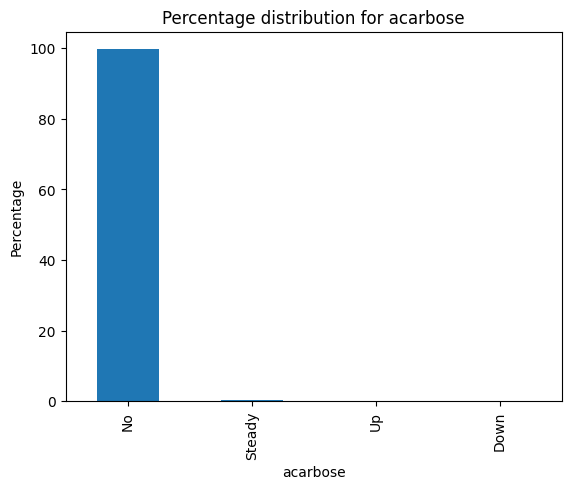

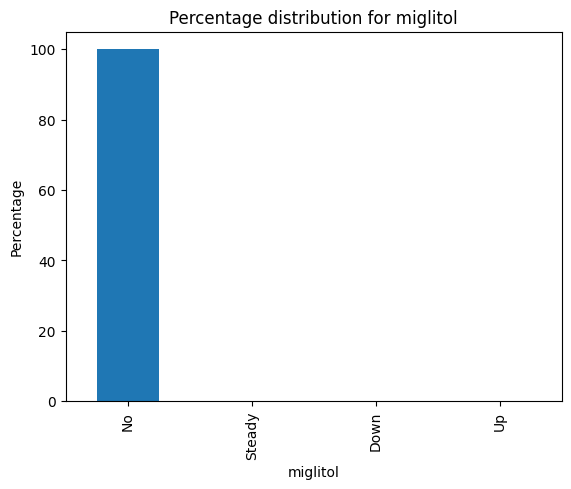

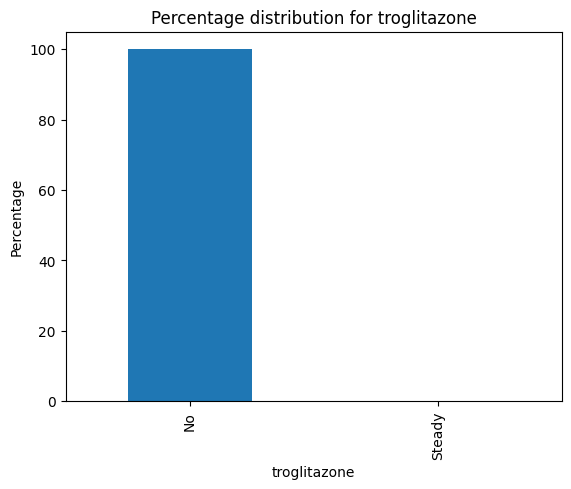

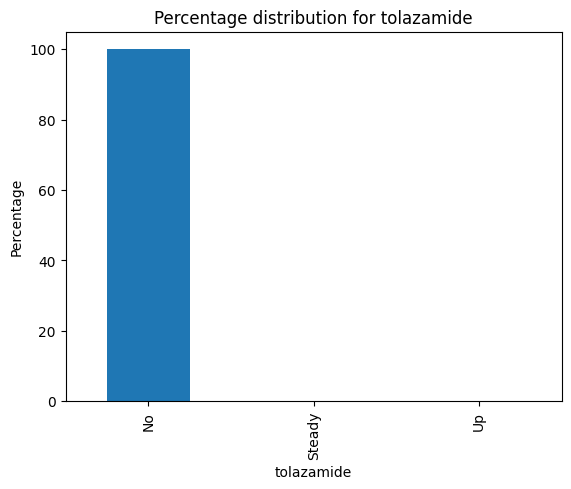

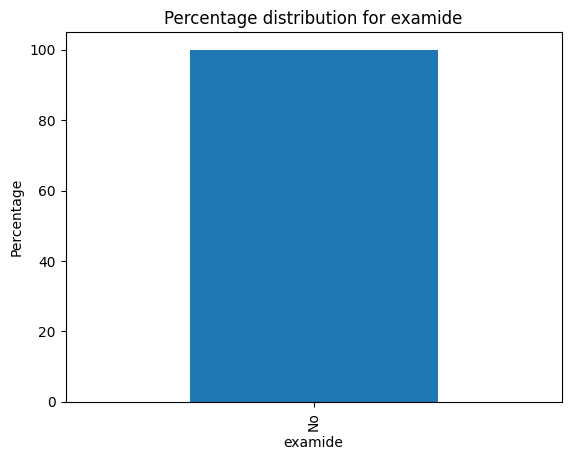

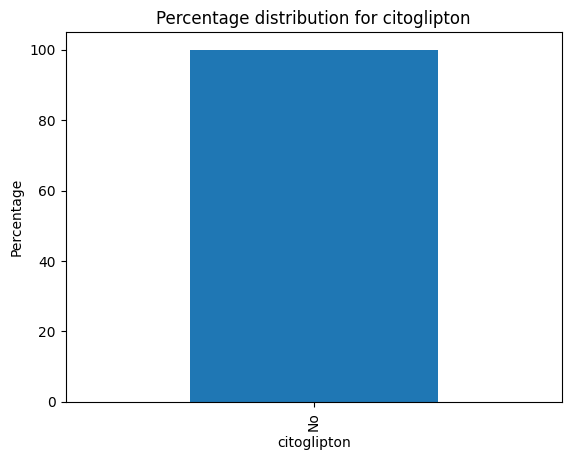

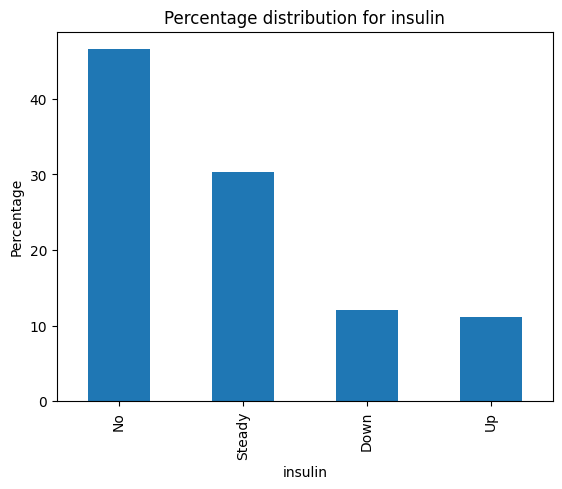

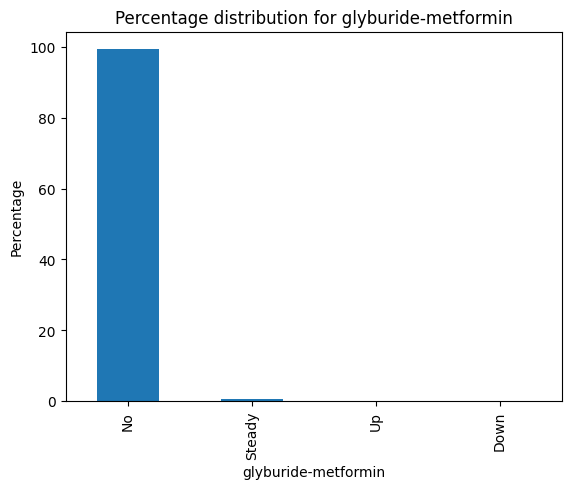

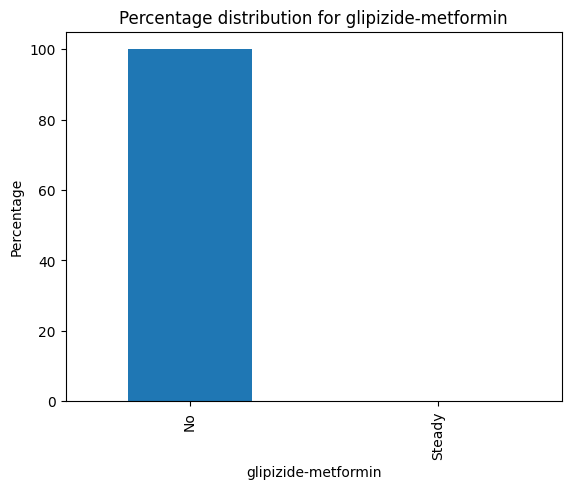

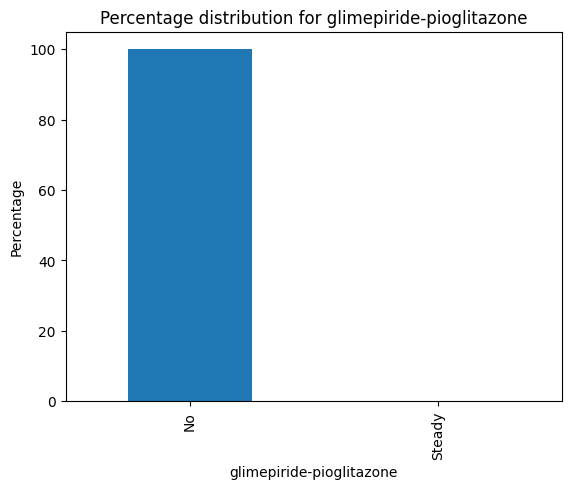

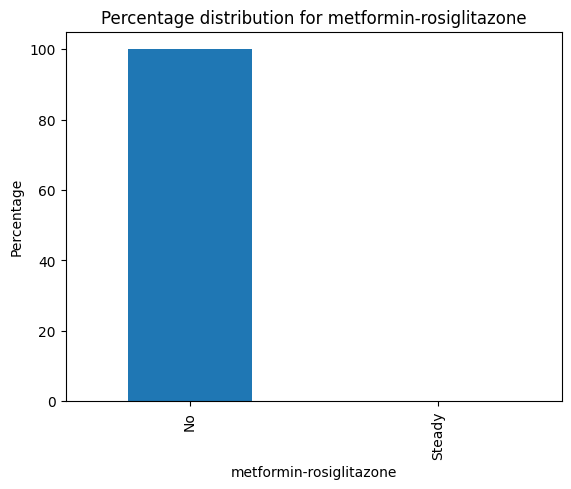

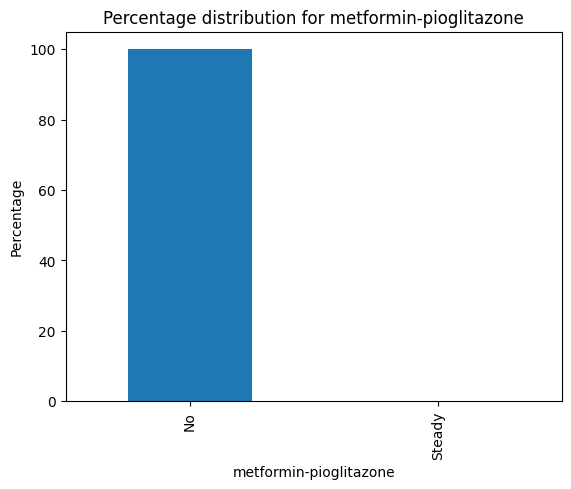

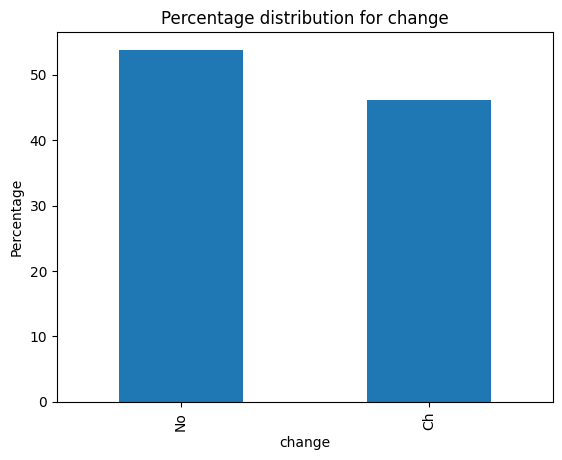

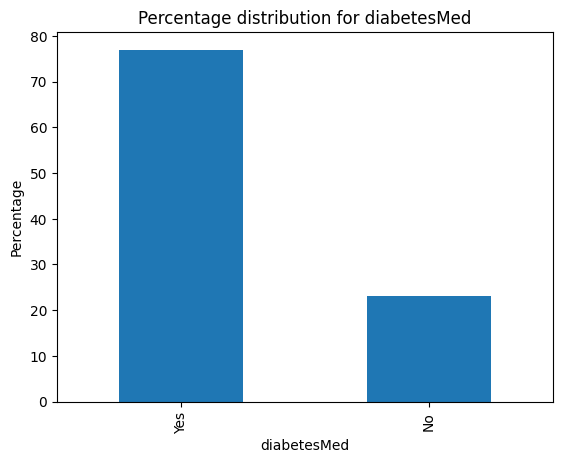

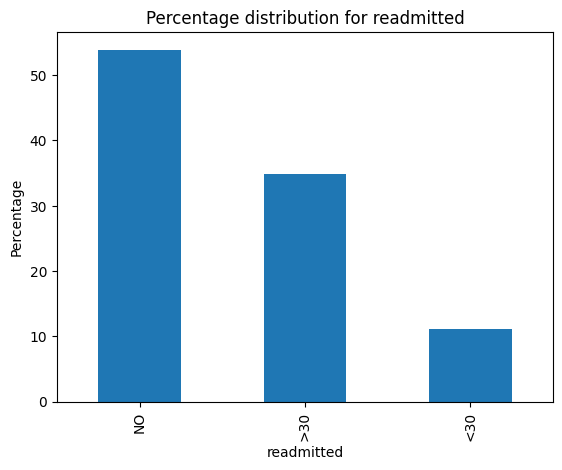

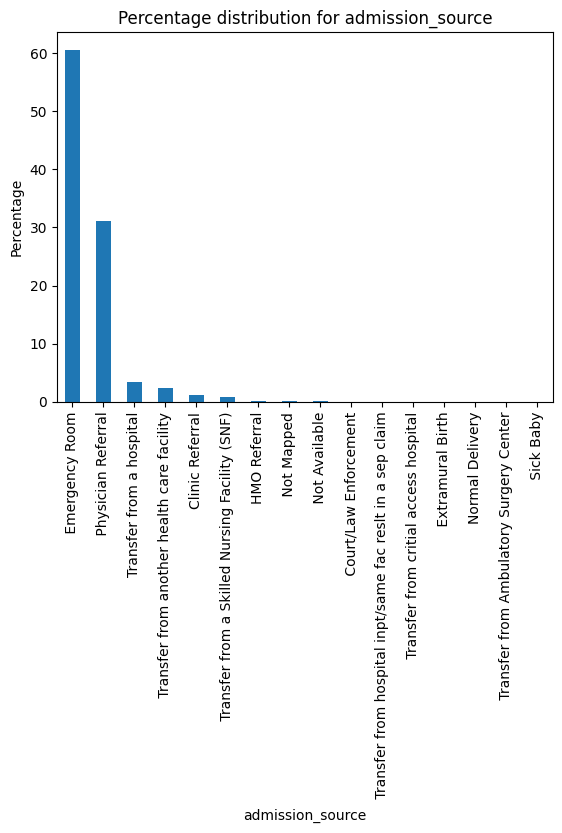

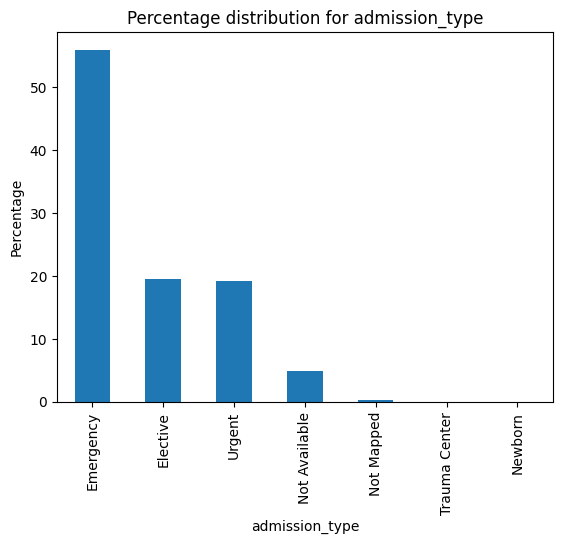

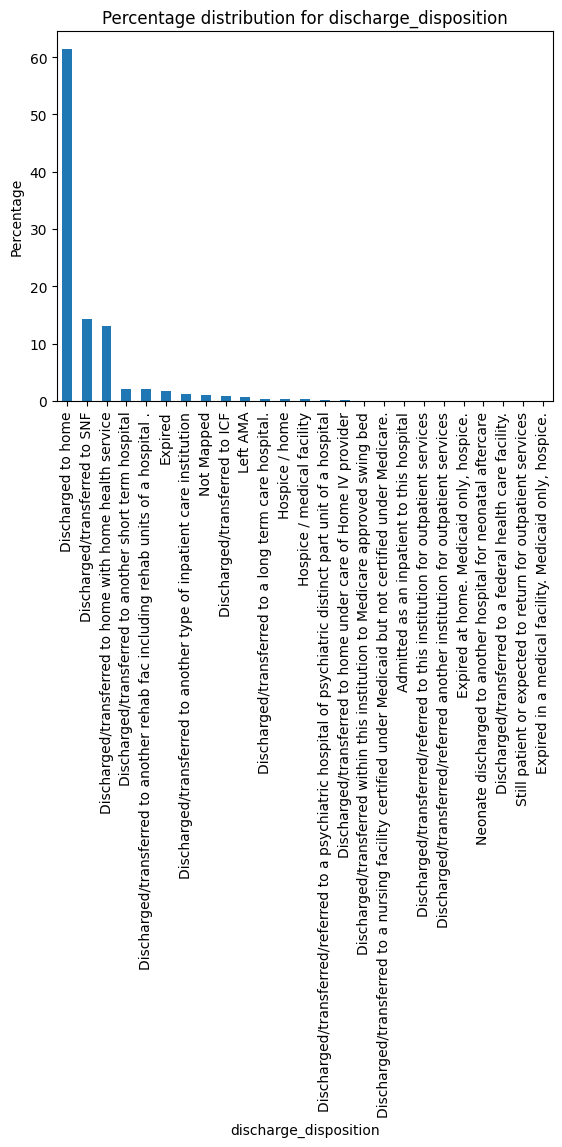

In [23]:
import matplotlib.pyplot as plt

for col in categorical_columns:
    percentage_distribution = df_diabetes[col].value_counts(normalize=True) * 100
    percentage_distribution.plot(kind='bar')
    plt.title(f"Percentage distribution for {col}")
    plt.ylabel('Percentage')
    plt.xlabel(col)
    plt.show()

In [24]:
# Function to find columns with >99% concentration in one category
def find_high_concentration_columns(df, threshold=99):
    high_concentration_columns = []
    categorical_columns = df.select_dtypes(include=['object']).columns

    for col in categorical_columns:
        max_percentage = df[col].value_counts(normalize=True).max() * 100
        if max_percentage > threshold:
            high_concentration_columns.append(col)

    return high_concentration_columns

# Get columns with >99% concentration
columns_with_high_concentration = find_high_concentration_columns(df_diabetes)
print("Columns with >99% concentration in one category:", columns_with_high_concentration)

Columns with >99% concentration in one category: ['nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


Since the >99% concentration in one category, these columns will not help the model, hence can be dropped.

Lets check the columns which has '?'.

In [25]:
# Initialize an empty list to store column names with '?'
quest_columns = []

# Initialize a dictionary to store the count of '?' occurrences in each column
quest_counts = {}

# Iterate over columns in the DataFrame
for x in df_diabetes.columns:
    # Check if any value in the column is equal to '?'
    if '?' in df_diabetes[x].values:
        quest_columns.append(x)
        # Count the number of '?' occurrences in the column
        quest_counts[x] = (df_diabetes[x] == '?').sum()

# Print the list of columns with '?' and their respective counts
print("Columns with '?' values:", quest_columns)
print("Number of '?' occurrences in each column:")
for col, count in quest_counts.items():
    print(f"{col}: {count}")

Columns with '?' values: ['race', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3']
Number of '?' occurrences in each column:
race: 2273
weight: 98569
payer_code: 40256
medical_specialty: 49949
diag_1: 21
diag_2: 358
diag_3: 1423


### Finding percentage of respective invalid values for each column

In [26]:
dict_invalid_values = {'race': '?', 'gender':'Unknown/Invalid','weight':'?','payer_code':'?','medical_specialty':'?', 'diag_1':'?', 'diag_2':'?', 'diag_3':'?'}

In [27]:
def invalid_values():
    for colname in dict_invalid_values:
        colname_invalid = (df_diabetes[colname]==dict_invalid_values[colname]).sum()
        colname_percentage_invalid = round((colname_invalid/df_diabetes[colname].count())*100,2)
        print(f"\033[1m{colname}\033[0m column has \033[1m{colname_invalid}\033[0m (\033[1m{colname_percentage_invalid} %\033[0m) invalid({dict_invalid_values[colname]}) values.")

In [28]:
invalid_values()

race column has 2273 (2.23 %) invalid(?) values.
gender column has 3 (0.0 %) invalid(Unknown/Invalid) values.
weight column has 98569 (96.86 %) invalid(?) values.
payer_code column has 40256 (39.56 %) invalid(?) values.
medical_specialty column has 49949 (49.08 %) invalid(?) values.
diag_1 column has 21 (0.02 %) invalid(?) values.
diag_2 column has 358 (0.35 %) invalid(?) values.
diag_3 column has 1423 (1.4 %) invalid(?) values.


As per the above information, we can impute the race column "?" values by most frequent value "Caucasian", delete the rows which has "Unknown/Invalid" in gender column, drop the weight column as it has 96% invalid values. We have to think about payer_code, medical_specialty as they have significant invalid values i.e., 40 and 50 % approx respectively.

For 'payer_code', we can replace "?" by 'MC', and for 'medical_specialty', we can replace "?" by 'InternalMedicine'. Here we are using most frequent value for imputation. Anyhow this should be reviewed by SME for relavence.

I think 'diag_1', 'diag_2' and 'diag_3' data should not be imputed, because it may be misleading as they are diagnosis data. Hence I think we should drop those rows as the percentage of invaled values are comparitively less. Again advise of SME will be helpful here.

### Imputation

In [29]:
# Taking copy of the data set
df_impute = df_diabetes.copy()

In [30]:
# No. of columns before dropping
df_impute.shape[1]

50

In [31]:
# Dropping 'max_glu_serum','A1Cresult', 'weight' columns.
df_impute.drop(['max_glu_serum','A1Cresult', 'weight'], axis=1, inplace=True)

In [32]:
# No. of columns after dropping
df_impute.shape[1]

47

In [33]:
# Handling null values
df_impute['admission_source'] = df_impute['admission_source'].fillna('Not Available')
df_impute['admission_type'] = df_impute['admission_type'].fillna('Not Available')
df_impute['discharge_disposition'] = df_impute['discharge_disposition'].fillna('Not Mapped')

In [34]:
# For race column, replace "?" by "Caucasian"
df_impute['race']= df_impute['race'].replace('?', 'Caucasian')
# For payer_code column, replace "?" by "MC"
df_impute['payer_code']= df_impute['payer_code'].replace('?', 'MC')
# For medical_specialty column, replace "?" by "InternalMedicine"
df_impute['medical_specialty']= df_impute['medical_specialty'].replace('?', 'InternalMedicine')

In [35]:
# Dropping rows with has less persentage of invalid values
drop_condition = ((df_impute['gender'] == 'Unknown/Invalid') | (df_impute['diag_1'] == '?') | (df_impute['diag_2'] == '?') | (df_impute['diag_3'] == '?'))
df_impute = df_impute[~drop_condition]

In [36]:
# Now there should not be any "?" in the dataset.
np.sum(df_impute.values == '?')

0

In [37]:
# Also there shouldn't be any null values
df_impute.isnull().sum()

encounter_id                0
patient_nbr                 0
race                        0
gender                      0
age                         0
time_in_hospital            0
payer_code                  0
medical_specialty           0
num_lab_procedures          0
num_procedures              0
num_medications             0
number_outpatient           0
number_emergency            0
number_inpatient            0
diag_1                      0
diag_2                      0
diag_3                      0
number_diagnoses            0
metformin                   0
repaglinide                 0
nateglinide                 0
chlorpropamide              0
glimepiride                 0
acetohexamide               0
glipizide                   0
glyburide                   0
tolbutamide                 0
pioglitazone                0
rosiglitazone               0
acarbose                    0
miglitol                    0
troglitazone                0
tolazamide                  0
examide   

In [38]:
# Now lets check the shape of the dataframe
print(f'Initial shape: {df_diabetes.shape}')
print(f'Shape after cleaning: {df_impute.shape}')
print(f'So, no. of rows deleted: {df_diabetes.shape[0]-df_impute.shape[0]} ({round(((df_diabetes.shape[0]-df_impute.shape[0])/df_diabetes.shape[0])*100,2)} %), and no. of columns deleted: {df_diabetes.shape[1]-df_impute.shape[1]}  ({round(((df_diabetes.shape[1]-df_impute.shape[1])/df_diabetes.shape[1])*100,2)} %)')

Initial shape: (101766, 50)
Shape after cleaning: (100241, 47)
So, no. of rows deleted: 1525 (1.5 %), and no. of columns deleted: 3  (6.0 %)


## Pre-processing

In [39]:
# Taking copy of the data set
df_cleaned = df_impute.copy()

In [40]:
# Duplication check
df_cleaned.duplicated().sum()

0

Exploring data again to check the no. of unique values to deciding on charecter encoding

In [41]:
print("Object columns and their corresponding total unique values:")
for x in df_cleaned.select_dtypes('object'):
    print(f' {x} - {df_cleaned[x].nunique()}', end=', ')

Object columns and their corresponding total unique values:
 race - 5,  gender - 2,  age - 10,  payer_code - 17,  medical_specialty - 72,  diag_1 - 715,  diag_2 - 743,  diag_3 - 789,  metformin - 4,  repaglinide - 4,  nateglinide - 4,  chlorpropamide - 4,  glimepiride - 4,  acetohexamide - 2,  glipizide - 4,  glyburide - 4,  tolbutamide - 2,  pioglitazone - 4,  rosiglitazone - 4,  acarbose - 4,  miglitol - 4,  troglitazone - 2,  tolazamide - 3,  examide - 1,  citoglipton - 1,  insulin - 4,  glyburide-metformin - 4,  glipizide-metformin - 2,  glimepiride-pioglitazone - 2,  metformin-rosiglitazone - 2,  metformin-pioglitazone - 2,  change - 2,  diabetesMed - 2,  readmitted - 3,  admission_source - 17,  admission_type - 7,  discharge_disposition - 25, 

In [42]:
print("Integer columns and their corresponding total unique values:")
for x in df_cleaned.select_dtypes('int'):
    print(f' {x} - {df_cleaned[x].nunique()}', end=', ')

Integer columns and their corresponding total unique values:
 encounter_id - 100241,  patient_nbr - 70413,  time_in_hospital - 14,  num_lab_procedures - 118,  num_procedures - 7,  num_medications - 75,  number_outpatient - 39,  number_emergency - 33,  number_inpatient - 20,  number_diagnoses - 14, 

Based on the numbers above, 
- we can apply one-hot encoding for the following columns: race, admission_type_id, discharge_disposition_id, admission_source_id, payer_code and all the medications except (acetohexamide, tolbutamide, troglitazone, glipizide-metformin, glimepiride-pioglitazone, metformin-rosiglitazone and metformin-pioglitazone, where we can use binary encoding).  
- We can apply binary encoding to the forllowing columns: gender, change, diabetesMed and all other medications mentioned before as exception for one-hot.
- We need to apply label/ordinal encoding for the age column.   
- We need to group and then aplly one-hot encoding (OR Target encoding) for other columns I guess: medical_specialty, diag_1, diag_2 and diag_3.  
- We can drop the following columns I guess: (encounter_id and patient_nbr as they are IDs) and (examide and citoglipton as they have only one unique value)

In [43]:
# Creating a list of columns which containg only 2 unique values
list_binary_encd = []
for x in df_cleaned.columns:
    if df_cleaned[x].nunique() == 2:
        list_binary_encd.append(x)

In [44]:
list_binary_encd

['gender',
 'acetohexamide',
 'tolbutamide',
 'troglitazone',
 'glipizide-metformin',
 'glimepiride-pioglitazone',
 'metformin-rosiglitazone',
 'metformin-pioglitazone',
 'change',
 'diabetesMed']

In [45]:
# Ordinal encoding for age column
df_cleaned['age'] = df_cleaned['age'].map({'[0-10)':1, '[10-20)':2, '[20-30)':3, '[30-40)':4, '[40-50)':5, '[50-60)':6, '[60-70)':7, '[70-80)':8, '[80-90)':9, '[90-100)':10})

In [46]:
df_cleaned['age'].unique()

array([ 2,  3,  4,  5,  6,  7,  8,  9, 10,  1])

In [47]:
# Chapter mapping based on ICD-9 chapters
icd9_chapter_mapping = {
    '001-139': '001-139', # 'Infectious And Parasitic Diseases'
    '140-239': '140-239', # 'Neoplasms'
    '240-279': '240-279', # 'Endocrine, Nutritional And Metabolic Diseases, And Immunity Disorders'
    '280-289': '280-289', # 'Diseases Of The Blood And Blood-Forming Organs'
    '290-319': '290-319', # 'Mental Disorders'
    '320-389': '320-389', # 'Diseases Of The Nervous System And Sense Organs'
    '390-459': '390-459', # 'Diseases Of The Circulatory System'
    '460-519': '460-519', # 'Diseases Of The Respiratory System'
    '520-579': '520-579', # 'Diseases Of The Digestive System'
    '580-629': '580-629', # 'Diseases Of The Genitourinary System'
    '630-679': '630-679', # 'Complications Of Pregnancy, Childbirth, And The Puerperium'
    '680-709': '680-709', # 'Diseases Of The Skin And Subcutaneous Tissue'
    '710-739': '710-739', # 'Diseases Of The Musculoskeletal System And Connective Tissue'
    '740-759': '740-759', # 'Congenital Anomalies'
    '760-779': '760-779', # 'Certain Conditions Originating In The Perinatal Period'
    '780-799': '780-799', # 'Symptoms, Signs, And Ill-Defined Conditions'
    '800-999': '800-999', # 'Injury And Poisoning'
    'V01-V91': 'V01-V91', # 'Supplementary Classification Of Factors Influencing Health Status And Contact With Health Services'
    'E000-E999': 'E000-E999' # 'Supplementary Classification Of External Causes Of Injury And Poisoning'
}

In [48]:
# Function to extract the chapter from the code
def get_chapter(icd_code):
    if icd_code == "?":
        return "?"
    elif icd_code.startswith('E'):
        return icd9_chapter_mapping['E000-E999']
    elif icd_code.startswith('V'):
        return icd9_chapter_mapping['V01-V91']
    else:
        for range_key, chapter_name in icd9_chapter_mapping.items():
            range_start, range_end = map(int, range_key.split('-'))
            code_num = int(icd_code.split('.')[0])
            if range_start <= code_num <= range_end:
                return chapter_name
    return 'Other'

In [49]:
# Define the grouping for medical_specialty column
grouping = {
    'Primary Care': [
        'InternalMedicine', 'Family/GeneralPractice', 'Pediatrics',
        'ObstetricsandGynecology', 'Pediatrics-Endocrinology',
        'Pediatrics-CriticalCare', 'Pediatrics-Pulmonology',
        'Pediatrics-Neurology', 'Pediatrics-EmergencyMedicine',
        'Pediatrics-InfectiousDiseases', 'Pediatrics-AllergyandImmunology',
        'Pediatrics-Hematology-Oncology', 'Obstetrics'
    ],
    'Surgery': [
        'Surgery-General', 'Orthopedics', 'Surgery-Cardiovascular/Thoracic',
        'Surgery-Neuro', 'Surgery-Colon&Rectal', 'Surgery-Plastic',
        'Surgery-Thoracic', 'Surgery-PlasticwithinHeadandNeck',
        'Surgery-Pediatric', 'Surgery-Maxillofacial', 'Surgery-Vascular',
        'Surgery-Cardiovascular', 'Orthopedics-Reconstructive'
    ],
    'Specialized Medicine': [
        'Cardiology', 'Gastroenterology', 'Nephrology', 'Psychiatry',
        'Emergency/Trauma', 'Pulmonology', 'Hematology/Oncology',
        'Otolaryngology', 'Endocrinology', 'Urology',
        'Psychiatry-Child/Adolescent', 'Neurology', 'Radiology',
        'Podiatry', 'Gynecology', 'Oncology', 'Psychology',
        'Ophthalmology', 'PhysicalMedicineandRehabilitation',
        'InfectiousDiseases', 'Rheumatology', 'AllergyandImmunology',
        'Hematology', 'Proctology', 'Pathology', 'Dermatology',
        'SportsMedicine', 'Cardiology-Pediatric', 'Neurophysiology',
        'Endocrinology-Metabolism', 'Obsterics&Gynecology-GynecologicOnco'
    ],
    'Other Services': [
        'Anesthesiology', 'Anesthesiology-Pediatric', 'Dentistry',
        'Surgeon', 'Osteopath', 'Psychiatry-Addictive',
        'PhysicianNotFound', 'SurgicalSpecialty', 'Radiologist',
        'Speech', 'Hospitalist', 'OutreachServices', 'Perinatology',
        'DCPTEAM', 'Resident'
    ]
}

In [50]:
# Function to categorize each specialty
def categorize_specialty(specialty):
    for group, specialties in grouping.items():
        if specialty in specialties:
            return group
    return specialty

In [51]:
admission_sources = {
    "Referrals": [
        "Clinic Referral",
        "Physician Referral",
        "HMO Referral"
    ],
    "Transfers": [
        "Transfer from a hospital",
        "Transfer from a Skilled Nursing Facility (SNF)",
        "Transfer from another health care facility",
        "Transfer from critial access hospital",
        "Transfer from hospital inpt/same fac reslt in a sep claim",
        "Transfer from Ambulatory Surgery Center"
    ],
    "Emergency and Law Enforcement": [
        "Emergency Room",
        "Court/Law Enforcement"
    ],
    "Special Circumstances": [
        "Extramural Birth",
        "Normal Delivery",
        "Sick Baby"
    ],
    "Uncategorized/Other": [
        "Not Mapped",
        "Not Available",
        "nan"  # Assuming 'nan' is used to represent missing data
    ]
}

In [52]:
# Function to categorize each admission source
def categorize_admission_source(source):
    for group, sources in admission_sources.items():
        if source in sources:
            return group
    return source

In [53]:
discharge_categories = {
    "Home Discharge": [
        "Discharged to home",
        "Discharged/transferred to home with home health service",
        "Discharged/transferred to home under care of Home IV provider",
        "Hospice / home"
    ],
    "Specialized Care Facilities": [
        "Discharged/transferred to SNF",
        "Discharged/transferred to ICF",
        "Discharged/transferred to a long term care hospital.",
        "Discharged/transferred to a nursing facility certified under Medicaid but not certified under Medicare.",
        "Discharged/transferred to a federal health care facility."
    ],
    "Hospitals & Rehab": [
        "Discharged/transferred to another short term hospital",
        "Discharged/transferred to another type of inpatient care institution",
        "Discharged/transferred to another rehab fac including rehab units of a hospital .",
        "Neonate discharged to another hospital for neonatal aftercare",
        "Discharged/transferred/referred to a psychiatric hospital of psychiatric distinct part unit of a hospital"
    ],
    "Within Institution": [
        "Discharged/transferred within this institution to Medicare approved swing bed",
        "Still patient or expected to return for outpatient services",
        "Discharged/transferred/referred to this institution for outpatient services"
    ],
    "Between Institutions": [
        "Discharged/transferred/referred another institution for outpatient services"
    ],
    "Hospice Care": [
        "Hospice / medical facility",
        "Expired in a medical facility. Medicaid only, hospice.",
        "Expired at home. Medicaid only, hospice."
    ],
    "Expired": [
        "Expired"
    ],
    "Admissions & AMA": [
        "Admitted as an inpatient to this hospital",
        "Left AMA (Against Medical Advice)"
    ],
    "Uncategorized": [
        "Not Mapped",
        "nan (Not Available/Not Applicable)"
    ]
}


In [54]:
# Function to categorize each discharge_disposition
def categorize_discharge_disposition(disposition):
    for group, dispositions in discharge_categories.items():
        if disposition in dispositions:
            return group
    return disposition

In [55]:
# Apply the function to each ICD code columns
df_cleaned['diag_1'] = df_cleaned['diag_1'].apply(get_chapter)
df_cleaned['diag_2'] = df_cleaned['diag_2'].apply(get_chapter)
df_cleaned['diag_3'] = df_cleaned['diag_3'].apply(get_chapter)


In [56]:
# Apply the categorization function to the medical_specialty column
df_cleaned['medical_specialty'] = df_cleaned['medical_specialty'].apply(categorize_specialty)

In [57]:
# Removing empty spaces in the text of admission_source column
df_cleaned['admission_source'] = df_cleaned['admission_source'].str.strip()

# Apply the categorization function to the admission_source column
df_cleaned['admission_source'] = df_cleaned['admission_source'].apply(categorize_admission_source)

In [58]:
# Removing empty spaces in the text of discharge_disposition column
df_cleaned['discharge_disposition'] = df_cleaned['discharge_disposition'].str.strip()

# Apply the categorization function to the discharge_disposition column
df_cleaned['discharge_disposition'] = df_cleaned['discharge_disposition'].apply(categorize_discharge_disposition)

In [59]:
# Dropping encounter_id and  patient_nbr columns.
df_cleaned.drop(['encounter_id','patient_nbr'], axis=1, inplace=True)

In [60]:
# Dropping columns_with_high_concentration.
df_cleaned.drop(columns_with_high_concentration, axis=1, inplace=True)

## Predection with Dataset (Not cleaned) without manually handling missing values

In [61]:
df_valmissing = df_diabetes.copy()

In [62]:
df_valmissing = df_valmissing.replace(["?", 'Unknown/Invalid'], np.nan)

In [63]:
# Ordinal encoding for age column
df_valmissing['age'] = df_valmissing['age'].map({'[0-10)':1, '[10-20)':2, '[20-30)':3, '[30-40)':4, '[40-50)':5, '[50-60)':6, '[60-70)':7, '[70-80)':8, '[80-90)':9, '[90-100)':10})

In [64]:
# Dropping 'max_glu_serum','A1Cresult', 'weight' columns.
df_valmissing.drop(['max_glu_serum','A1Cresult', 'weight'], axis=1, inplace=True)

In [65]:
# Dropping encounter_id and  patient_nbr columns.
df_valmissing.drop(['encounter_id','patient_nbr'], axis=1, inplace=True)

In [66]:
df_valmissing.replace(' ', '_', regex=True, inplace=True)

In [67]:
X = df_valmissing.drop('readmitted', axis=1).copy()

In [68]:
y = df_valmissing['readmitted'].copy()

In [69]:
X.columns = X.columns.str.replace('-', '_')

In [70]:
object_columns = X.select_dtypes('object').columns

In [71]:
X_encoded = pd.get_dummies(X, columns= object_columns)

In [72]:
y = y.map({'<30':0, '>30':0, 'NO':1})

In [73]:
y.head()

0    1
1    0
2    1
3    1
4    1
Name: readmitted, dtype: int64

In [74]:
sum(y)/len(y)

0.5391191557101586

In [75]:
from sklearn.model_selection import train_test_split

In [76]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y , random_state=42, stratify=y)

In [77]:
sum(y_test)/len(y_test)

0.5391085606477478

In [78]:
import xgboost as xgb

In [79]:
clf_xgb = xgb.XGBClassifier(objective='binary:logistic', early_stopping_rounds = 10, eval_metric = 'aucpr', missing= np.nan, seed=42)
clf_xgb.fit(X_train, y_train, verbose=True, eval_set=[(X_test, y_test)])

[0]	validation_0-aucpr:0.69620
[1]	validation_0-aucpr:0.70323
[2]	validation_0-aucpr:0.70755
[3]	validation_0-aucpr:0.71128
[4]	validation_0-aucpr:0.71306
[5]	validation_0-aucpr:0.71548
[6]	validation_0-aucpr:0.71653
[7]	validation_0-aucpr:0.71812
[8]	validation_0-aucpr:0.71989
[9]	validation_0-aucpr:0.72054
[10]	validation_0-aucpr:0.72166
[11]	validation_0-aucpr:0.72301
[12]	validation_0-aucpr:0.72415
[13]	validation_0-aucpr:0.72559
[14]	validation_0-aucpr:0.72716
[15]	validation_0-aucpr:0.72767
[16]	validation_0-aucpr:0.72785
[17]	validation_0-aucpr:0.72817
[18]	validation_0-aucpr:0.72825
[19]	validation_0-aucpr:0.72884
[20]	validation_0-aucpr:0.72912
[21]	validation_0-aucpr:0.72897
[22]	validation_0-aucpr:0.72931
[23]	validation_0-aucpr:0.72958
[24]	validation_0-aucpr:0.73006
[25]	validation_0-aucpr:0.73025
[26]	validation_0-aucpr:0.73030
[27]	validation_0-aucpr:0.73056
[28]	validation_0-aucpr:0.73068
[29]	validation_0-aucpr:0.73065
[30]	validation_0-aucpr:0.73045
[31]	validation_0-

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=10,
              enable_categorical=False, eval_metric='aucpr', feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [80]:
y_pred_XGB = clf_xgb.predict(X_test)
y_pred_XGB_proba = clf_xgb.predict_proba(X_test)

In [81]:
# Function for evaluation metrices
def eval_metrics(y_test, y_pred):
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    conf_matrix = confusion_matrix(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    # Print metrics
    print("\nModel Report")
    print(f"Accuracy: {accuracy}")
    print(f"Confusion Matrix:\n{conf_matrix}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}")

In [82]:
eval_metrics(y_test, y_pred_XGB)


Model Report
Accuracy: 0.6476692083955664
Confusion Matrix:
[[ 6373  5353]
 [ 3611 10105]]
Precision: 0.6466157712200967
Recall: 0.6476692083955664
F1 Score: 0.6440527407568011


In [83]:
print(classification_report(y_test, y_pred_XGB))

              precision    recall  f1-score   support

           0       0.64      0.54      0.59     11726
           1       0.65      0.74      0.69     13716

    accuracy                           0.65     25442
   macro avg       0.65      0.64      0.64     25442
weighted avg       0.65      0.65      0.64     25442



## Predection with cleaned dataset

In [84]:
X_cleaned = df_cleaned.drop('readmitted', axis=1).copy()
y_cleaned = df_cleaned['readmitted'].copy()
X_cleaned.columns = X_cleaned.columns.str.replace('-', '_')
object_columns = X_cleaned.select_dtypes('object').columns
X_cleaned_encoded = pd.get_dummies(X_cleaned, columns= object_columns)
y_cleaned = y_cleaned.map({'<30':0, '>30':0, 'NO':1})
X_cleaned_train, X_cleaned_test, y_cleaned_train, y_cleaned_test = train_test_split(X_cleaned_encoded, y_cleaned , random_state=42, stratify=y_cleaned)
clf_xgb = xgb.XGBClassifier(objective='binary:logistic', early_stopping_rounds = 10, eval_metric = 'aucpr', seed=42)
clf_xgb.fit(X_cleaned_train, y_cleaned_train, verbose=True, eval_set=[(X_cleaned_test, y_cleaned_test)])
y_cleaned_pred_XGB = clf_xgb.predict(X_cleaned_test)

[0]	validation_0-aucpr:0.69490
[1]	validation_0-aucpr:0.70435
[2]	validation_0-aucpr:0.70718
[3]	validation_0-aucpr:0.70990
[4]	validation_0-aucpr:0.71261
[5]	validation_0-aucpr:0.71550
[6]	validation_0-aucpr:0.71729
[7]	validation_0-aucpr:0.71947
[8]	validation_0-aucpr:0.72047
[9]	validation_0-aucpr:0.72160
[10]	validation_0-aucpr:0.72329
[11]	validation_0-aucpr:0.72466
[12]	validation_0-aucpr:0.72494
[13]	validation_0-aucpr:0.72537
[14]	validation_0-aucpr:0.72619
[15]	validation_0-aucpr:0.72659
[16]	validation_0-aucpr:0.72667
[17]	validation_0-aucpr:0.72702
[18]	validation_0-aucpr:0.72720
[19]	validation_0-aucpr:0.72741
[20]	validation_0-aucpr:0.72745
[21]	validation_0-aucpr:0.72838
[22]	validation_0-aucpr:0.72847
[23]	validation_0-aucpr:0.72857
[24]	validation_0-aucpr:0.72868
[25]	validation_0-aucpr:0.72921
[26]	validation_0-aucpr:0.72932
[27]	validation_0-aucpr:0.72896
[28]	validation_0-aucpr:0.72892
[29]	validation_0-aucpr:0.72880
[30]	validation_0-aucpr:0.72884
[31]	validation_0-

In [85]:
eval_metrics(y_cleaned_test, y_cleaned_pred_XGB)


Model Report
Accuracy: 0.6414348988468138
Confusion Matrix:
[[6272 5334]
 [3652 9803]]
Precision: 0.6403868657992593
Recall: 0.6414348988468138
F1 Score: 0.6379754798830074


## Predection without One-hot-encoding - Dataset not cleaned  
(Applying categorical features as it is, missing and invalid values imputed to retained as NaN)

In [86]:
for x in X.select_dtypes('object').columns:
    X[x] = X[x].astype('category')

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y)

In [88]:
# Create and train the model using scikit-learn API
model = xgb.XGBClassifier(use_label_encoder=False, enable_categorical=True, objective='binary:logistic', early_stopping_rounds = 10, eval_metric = 'aucpr', missing= np.nan, seed=42)
model.fit(X_train, y_train, verbose=True, eval_set=[(X_test, y_test)])

# Make predictions
predictions = model.predict(X_test)

# Evaluate the model
eval_metrics(y_test, predictions)

[0]	validation_0-aucpr:0.69414
[1]	validation_0-aucpr:0.70261
[2]	validation_0-aucpr:0.70836
[3]	validation_0-aucpr:0.71519
[4]	validation_0-aucpr:0.71714
[5]	validation_0-aucpr:0.71794
[6]	validation_0-aucpr:0.71892
[7]	validation_0-aucpr:0.71743
[8]	validation_0-aucpr:0.71776
[9]	validation_0-aucpr:0.71729
[10]	validation_0-aucpr:0.71821
[11]	validation_0-aucpr:0.71796
[12]	validation_0-aucpr:0.71804
[13]	validation_0-aucpr:0.71873
[14]	validation_0-aucpr:0.71865
[15]	validation_0-aucpr:0.71850
[16]	validation_0-aucpr:0.71755

Model Report
Accuracy: 0.6339124282682179
Confusion Matrix:
[[ 5693  6033]
 [ 3281 10435]]
Precision: 0.6339919408817508
Recall: 0.6339124282682179
F1 Score: 0.6262661900050908


In [89]:
def feature_imp(model_name):
    # 'get_booster().get_fscore()' returns a dictionary of feature importances
    feat_imp = pd.Series(model_name.get_booster().get_fscore()).sort_values(ascending=False)

    # Set the figure size to make it wider
    plt.figure(figsize=(16, 6))
    
    # Create a bar plot
    feat_imp.plot(kind='bar', title='Feature Importances')
    
    # Set the y-axis label
    plt.ylabel('Feature Importance Score')
    
    # Rotate the x-axis labels for better readability
    plt.xticks(rotation=90)
    
    # Adjust the layout to prevent labels from overlapping
    plt.tight_layout()
    
    # Show the plot
    plt.show()    

#### Feature Importance (Not cleaned)

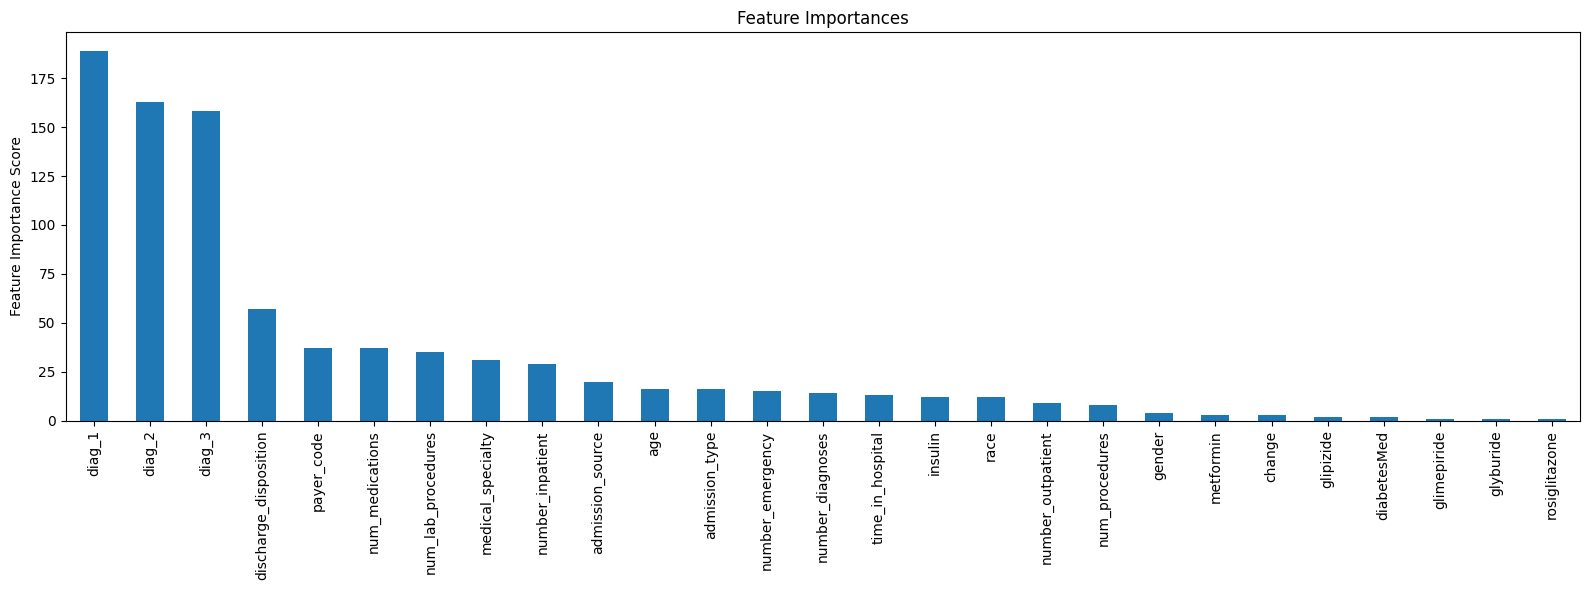

In [90]:
feature_imp(model)

## Predection with cleaned dataset, but without One hot encoding

In [91]:
for x in X_cleaned.select_dtypes('object').columns:
    X_cleaned[x] = X_cleaned[x].astype('category')

In [92]:
X_cleaned_train, X_cleaned_test, y_cleaned_train, y_cleaned_test = train_test_split(X_cleaned, y_cleaned , random_state=42, stratify=y_cleaned)
clf_xgb = xgb.XGBClassifier(use_label_encoder=False, enable_categorical=True, objective='binary:logistic', early_stopping_rounds = 10, eval_metric = 'aucpr', seed=42)
clf_xgb.fit(X_cleaned_train, y_cleaned_train, verbose=True, eval_set=[(X_cleaned_test, y_cleaned_test)])
y_cleaned_pred_XGB = clf_xgb.predict(X_cleaned_test)
eval_metrics(y_cleaned_test, y_cleaned_pred_XGB)

[0]	validation_0-aucpr:0.69854
[1]	validation_0-aucpr:0.70822
[2]	validation_0-aucpr:0.71251
[3]	validation_0-aucpr:0.71547
[4]	validation_0-aucpr:0.71704
[5]	validation_0-aucpr:0.71883
[6]	validation_0-aucpr:0.72081
[7]	validation_0-aucpr:0.72178
[8]	validation_0-aucpr:0.72244
[9]	validation_0-aucpr:0.72324
[10]	validation_0-aucpr:0.72345
[11]	validation_0-aucpr:0.72388
[12]	validation_0-aucpr:0.72438
[13]	validation_0-aucpr:0.72556
[14]	validation_0-aucpr:0.72625
[15]	validation_0-aucpr:0.72616
[16]	validation_0-aucpr:0.72675
[17]	validation_0-aucpr:0.72637
[18]	validation_0-aucpr:0.72657
[19]	validation_0-aucpr:0.72694
[20]	validation_0-aucpr:0.72715
[21]	validation_0-aucpr:0.72702
[22]	validation_0-aucpr:0.72692
[23]	validation_0-aucpr:0.72639
[24]	validation_0-aucpr:0.72663
[25]	validation_0-aucpr:0.72698
[26]	validation_0-aucpr:0.72693
[27]	validation_0-aucpr:0.72720
[28]	validation_0-aucpr:0.72735
[29]	validation_0-aucpr:0.72744
[30]	validation_0-aucpr:0.72752
[31]	validation_0-

#### Feature Importance (cleaned dataset)

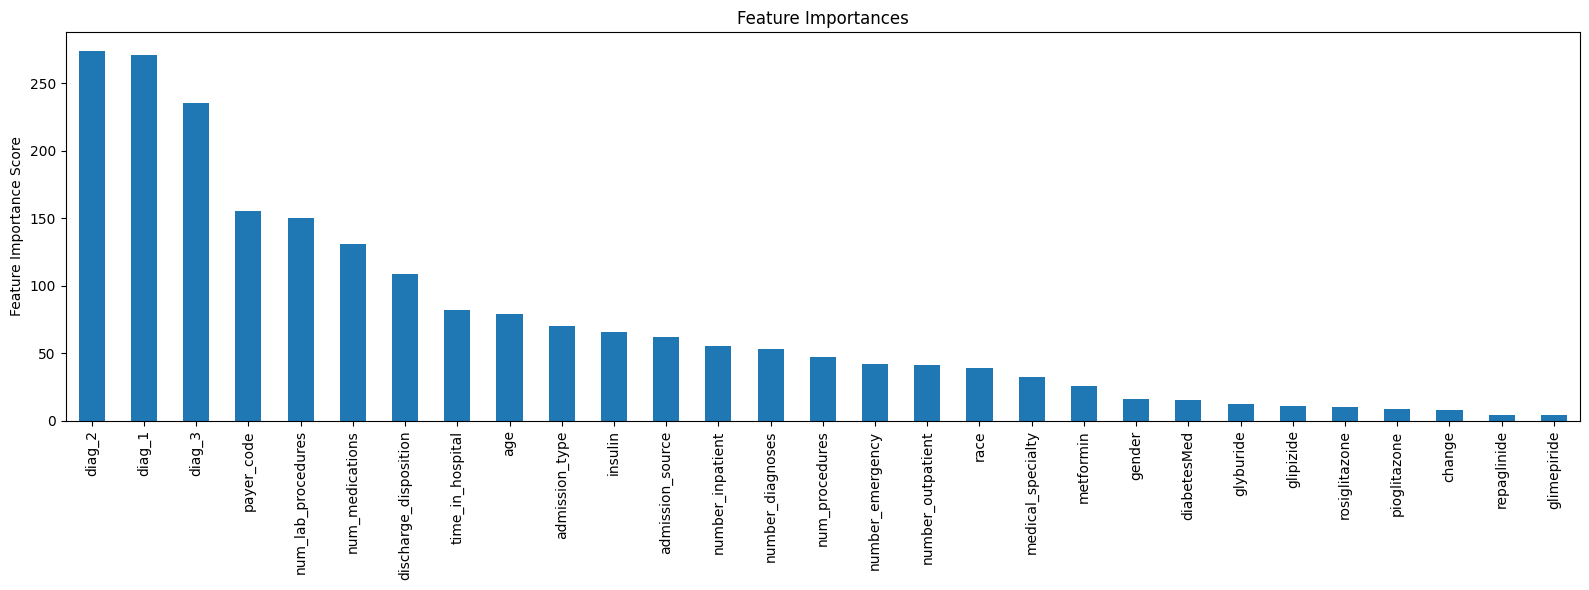

In [93]:
feature_imp(clf_xgb)

## Predection with Cleaned dataset with Cross Validation

In [94]:
df_cleaned['readmitted'] = df_cleaned['readmitted'].map({'<30':0, '>30':0, 'NO':1})
dtrain= pd.get_dummies(df_cleaned, drop_first=True)
train = dtrain
target = 'readmitted'

In [95]:
def modelfit(alg, dtrain, predictors,useTrainCV=True, cv_folds=5, early_stopping_rounds=50):
    
    if useTrainCV:
        xgb_param = alg.get_xgb_params()
        xgtrain = xgb.DMatrix(dtrain[predictors].values, label=dtrain[target].values)
        cvresult = xgb.cv(xgb_param, xgtrain, num_boost_round=alg.get_params()['n_estimators'],
                          nfold=cv_folds,metrics='auc', early_stopping_rounds=early_stopping_rounds)
        alg.set_params(n_estimators=cvresult.shape[0])
    
    #Fit the algorithm on data
    alg.fit(dtrain[predictors], dtrain['readmitted'])
        
    #Predict training set:
    dtrain_predictions = alg.predict(dtrain[predictors])
        
    #Print model report:
    eval_metrics(dtrain['readmitted'].values, dtrain_predictions)

In [96]:
predictors = [x for x in train.columns if x not in [target]]
xgb2 = xgb.XGBClassifier(
    learning_rate=0.1,
    n_estimators=1000,
    max_depth=5,
    min_child_weight=1,
    gamma=0,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    nthread=4,
    scale_pos_weight=1,
    seed=27
)

In [97]:
modelfit(xgb2, train, predictors)


Model Report
Accuracy: 0.6766592512045969
Confusion Matrix:
[[27193 19230]
 [13182 40636]]
Precision: 0.6763411805855195
Recall: 0.6766592512045969
F1 Score: 0.6739950970129512


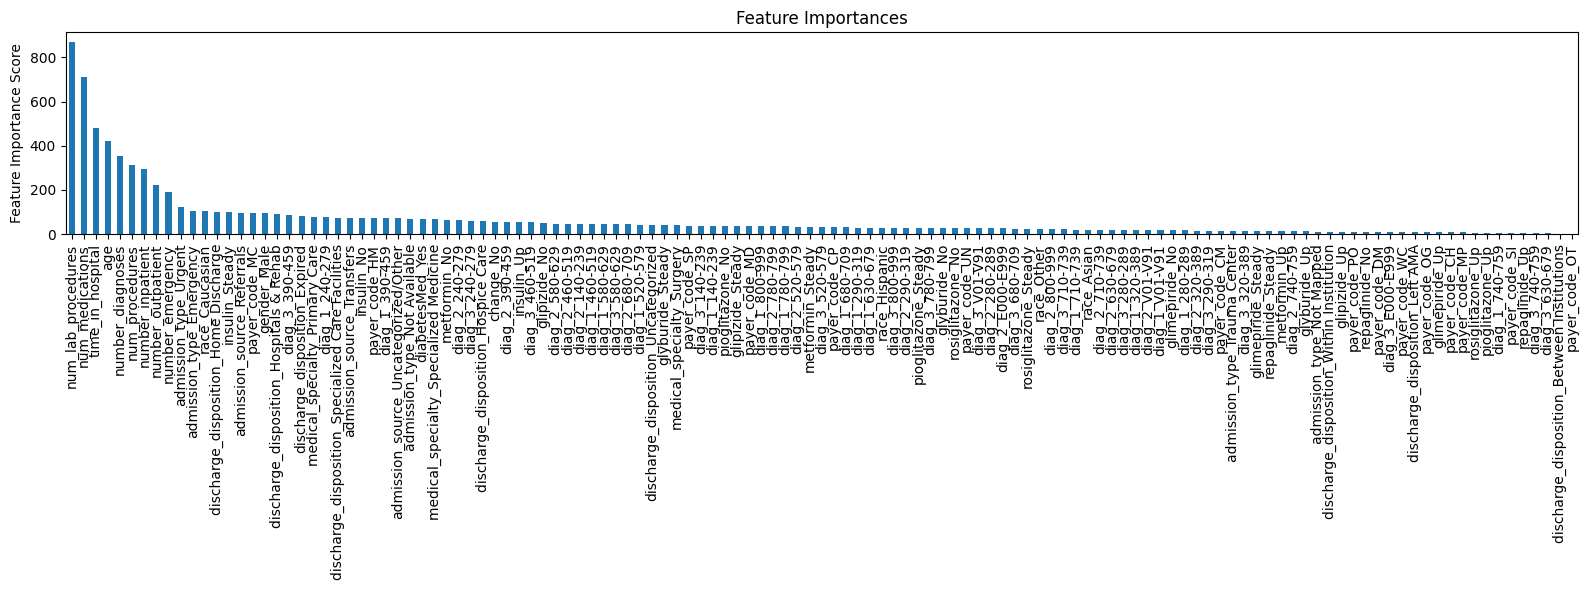

In [98]:
feature_imp(xgb2)

### Predection with cross validation, but with dataset not cleaned

In [99]:
df_valmissing['readmitted'] = df_valmissing['readmitted'].map({'<30':0, '>30':0, 'NO':1})
dtrain= pd.get_dummies(df_valmissing, drop_first=True)
train = dtrain
target = 'readmitted'

In [100]:
predictors = [x for x in train.columns if x not in [target]]
xgb3 = xgb.XGBClassifier(
    learning_rate=0.1,
    n_estimators=1000,
    max_depth=5,
    min_child_weight=1,
    gamma=0,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='auc',
    missing=np.nan,
    nthread=4,
    scale_pos_weight=1,
    seed=27
)

In [101]:
modelfit(xgb3, train, predictors)


Model Report
Accuracy: 0.6884028064382997
Confusion Matrix:
[[27916 18986]
 [12724 42140]]
Precision: 0.6882498207135229
Recall: 0.6884028064382997
F1 Score: 0.6856694810731843


This gives bit more accuracy, but takes too much time to run. It is expected because it results in high dimention as the data are not grouped. Hence it's not good to consider this model I assume. So, to continue tuning parameters with cleaned dataset is better I guess.